In [38]:
import sqlite3      # Library for  working with the SQLite database
import pandas as pd
import matplotlib.pyplot as plt

# Create connection to the SQLite database
conn = sqlite3.connect('Chinook_Sqlite.sqlite')

def run_query(query):
    """Function to run the SQL queries and easily return the results as a pandas DataFrame."""
    return pd.read_sql_query(query, conn)   # Tool from pd to process the SQL query and return the results as a DataFrame. Uses the query and "conn", which is basically the database we're working with.

In [39]:
# Gathering what are the tables before starting to query the database.

query_schema = """ SELECT name FROM sqlite_master WHERE type = 'table'; """

all_tables = run_query(query_schema)
display(all_tables)  # Display a dataframe with the tables in the database.

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


In [40]:
print("Relations between tables in the CHINOOK database\n\n")   # Title for reporting the relations between tables in the database.

# For loop to iterate through the tables in the dataframe from previous cell.
for table in all_tables['name']:
    
    # Using PRAGMA command from SQLite to get another dataframe covering the existing relations between all tables.
    query_relations = f"PRAGMA foreign_key_list({table});"
    relations = run_query(query_relations)
    
    # If the table has relations, print a topic withe the table name, its connections and the columns that connect them.
    if not relations.empty:
        print(f"Table '{table}' is connected to:")
        for index, row in relations.iterrows():
            print(f" -> '{row['table']}' (by column '{row['from']}')\n")
    

Relations between tables in the CHINOOK database


Table 'Album' is connected to:
 -> 'Artist' (by column 'ArtistId')

Table 'Customer' is connected to:
 -> 'Employee' (by column 'SupportRepId')

Table 'Employee' is connected to:
 -> 'Employee' (by column 'ReportsTo')

Table 'Invoice' is connected to:
 -> 'Customer' (by column 'CustomerId')

Table 'InvoiceLine' is connected to:
 -> 'Track' (by column 'TrackId')

 -> 'Invoice' (by column 'InvoiceId')

Table 'PlaylistTrack' is connected to:
 -> 'Track' (by column 'TrackId')

 -> 'Playlist' (by column 'PlaylistId')

Table 'Track' is connected to:
 -> 'MediaType' (by column 'MediaTypeId')

 -> 'Genre' (by column 'GenreId')

 -> 'Album' (by column 'AlbumId')



In [41]:
# Defining a function to plot the results of the queries in a bar chart.

def plot_bar_chart(xdata, ydata, xlabel, ylabel, title):
    """Function to plot the results of the queries in a bar chart."""

    plt.figure(figsize=(8, 4))   # Create a new figure with a specified size.

    plt.bar(xdata, ydata, color='skyblue')  # Create a bar chart with data from the DataFrame.

    # Defining the chart's title and labels.
    plt.title(title, fontsize=14)    # Chart title.
    plt.xlabel(xlabel, fontsize=12)     # X-axis label.
    plt.ylabel(ylabel, fontsize=12)   # Y-axis label.

    plt.xticks(rotation=45)    # Rotate x-axis labels for better readability.


    plt.tight_layout()  # Adjust the layout to prevent overlapping.
    plt.show()      # Display the chart.


In [42]:
# Defining a function to plot the results of the queries in a horizontal bar chart.

def plot_hbar_chart(ydata, xdata, ylabel, xlabel, title):
    """Function to plot the results of the queries in a horizontal bar chart."""

    plt.figure(figsize=(8, 4))   # Create a new figure with a specified size.

    plt.barh(ydata, xdata, color='coral')  # Create a horizontal bar chart with data from the DataFrame.

    # Defining the chart's title and labels.
    plt.title(title, fontsize=14)    # Chart title.
    plt.xlabel(xlabel, fontsize=12)     # X-axis label.
    plt.ylabel(ylabel, fontsize=12)   # Y-axis label.

    plt.tight_layout()  # Adjust the layout to prevent overlapping.
    plt.show()      # Display the chart.



In [43]:
# Defining a function to plot the results of the queries in a pie chart.

def plot_pie_chart(data, labels, title):
    """Function to plot the results of the queries in a pie chart."""

    plt.figure(figsize=(6, 6))   # Create a new figure with a square size to have the pir chart perfectly round.

    plt.pie(data, labels=labels, autopct='%1.1f%%') # "data" is the data to be plotted, "labels" is the labels for each slice, and "autopct" is the format for displaying the percentage on each slice.

    # Defining the chart's title.
    plt.title(title, fontsize=14)

    plt.tight_layout()  # Adjust the layout to prevent overlapping.
    plt.show()      # Display the chart.

,SongID,Quantity_Sold,Song_Name
0,2,2,Balls to the Wall
1,8,2,Inject The Venom
2,9,2,Snowballed
3,20,2,Overdose
4,32,2,Deuces Are Wild
5,48,2,Not The Doctor
6,66,2,Por Causa De Você
7,84,2,Welcome Home (Sanitarium)
8,161,2,Snowblind
9,162,2,Cornucopia


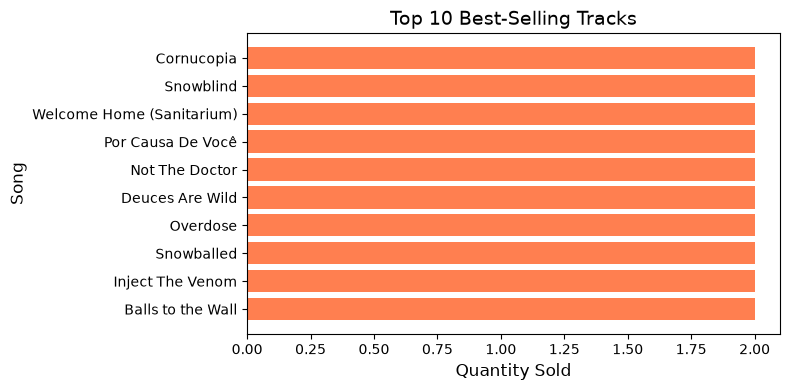

In [44]:
# Which are the 10 best-selling tracks?

query_top_tracks = """
SELECT t.TrackId AS SongID, SUM(i.Quantity) AS Quantity_Sold, t.Name AS Song_Name
FROM Track t JOIN InvoiceLine i
ON i.TrackId = t.TrackId
GROUP BY SongID
ORDER BY Quantity_Sold DESC
LIMIT 10;
"""

top_tracks = run_query(query_top_tracks)
display(top_tracks)

inverted_top_tracks = top_tracks.sort_values(by='Quantity_Sold', ascending=True)  # Sort the DataFrame in ascending order to plot an accurate horizontal bar chart.

plot_hbar_chart(inverted_top_tracks['Song_Name'], inverted_top_tracks['Quantity_Sold'], 'Song', 'Quantity Sold', 'Top 10 Best-Selling Tracks')

,Country,Total_Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48


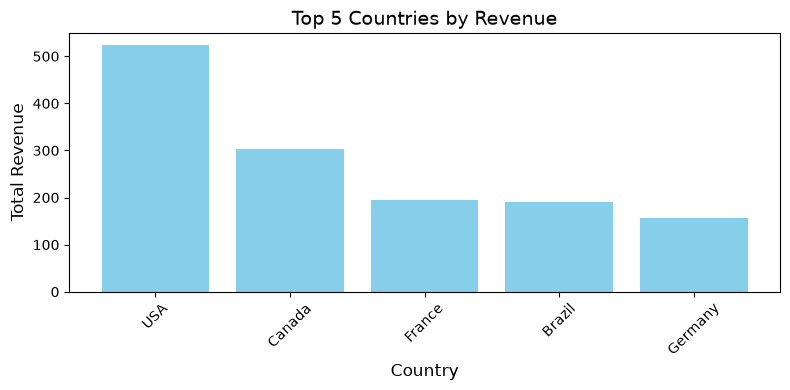

In [45]:
# Which country generates the most revenue?

query_top_countries = """
SELECT BillingCountry AS Country, SUM(Total) AS Total_Revenue
FROM Invoice
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

top_countries = run_query(query_top_countries)
display(top_countries)

plot_bar_chart(top_countries['Country'], top_countries['Total_Revenue'], 'Country', 'Total Revenue', 'Top 5 Countries by Revenue')


,Total_Sales,Employee_Name
0,833.04,Jane Peacock
1,775.40,Margaret Park
2,720.16,Steve Johnson


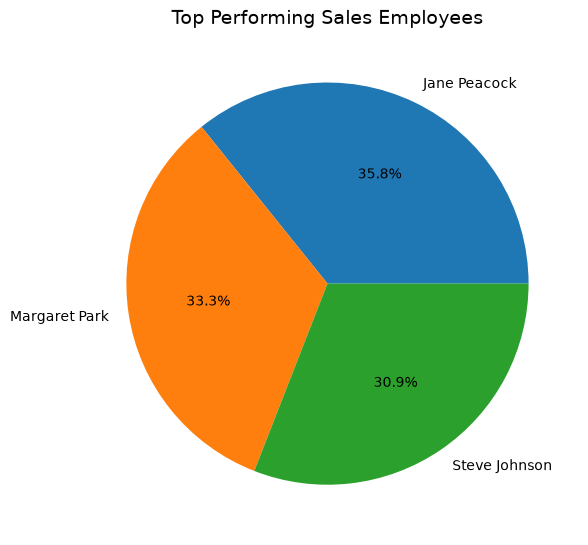

In [46]:
# Who is the top-performing sales employee?

query_top_employees = """
SELECT SUM(i.Total) AS Total_Sales, e.FirstName || ' ' || e.LastName AS Employee_Name
FROM Invoice i
JOIN Customer c ON i.CustomerId = c.CustomerId
JOIN Employee e ON c.SupportRepId = e.EmployeeId
GROUP BY Employee_Name
ORDER BY Total_Sales DESC LIMIT 5;
"""

top_employees = run_query(query_top_employees)
display(top_employees)

plot_pie_chart(top_employees['Total_Sales'], top_employees['Employee_Name'], 'Top Performing Sales Employees')